# Data Science Libraries

## Numpy (Numerical Python Library)

**The Problem with Plain Python for Numbers**

Lists are general purpose as they are very flexible

- But while operating on a large dataset it consumes significant memory and time complecxity required to solve a problem is very high

Consider a real scenario: you have **10,000 invoice amounts** and need to apply 13% VAT to all of them.




In [1]:
%%time
gross_amount = [23, 89, 78, 89, 792, 797, 89, 78, 89, 792, 797, 89, 78, 89, 792, 797]
net_amount = []

for amount in gross_amount:
    net = amount * 1.13  # Assuming a tax rate of 20%
    net_amount.append(net)

CPU times: user 8 μs, sys: 0 ns, total: 8 μs
Wall time: 10.3 μs


In [2]:
import numpy as np

In [3]:
gross_array = np.array(gross_amount)
gross_array = gross_array * 1.13  # Assuming a tax rate of 20%
gross_array

array([ 25.99, 100.57,  88.14, 100.57, 894.96, 900.61, 100.57,  88.14,
       100.57, 894.96, 900.61, 100.57,  88.14, 100.57, 894.96, 900.61])

**The NumPy approach:**
- Numbers are stored as raw C-level data in a single contiguous block of memory
- Operations apply to the **entire block at once** using optimised C/Fortran code
- For 10,000 invoices → 1 operation


| Scenario | Records | Python List | NumPy Array |
|----------|---------|-------------|-------------|
| VAT on invoices | 10,000 | ~50 ms | ~0.1 ms (500× faster) |
| Payroll calculations | 50,000 | ~250 ms | ~0.5 ms |
| Stock return analysis | 1,000,000 | ~5 sec | ~10 ms |
| Trial balance ratios | 500 accounts | instant | instant |

The gap widens dramatically as data grows. This is why every serious financial analytics tool is built on NumPy.

In [4]:
import time

n = 100_000_000
amounts_list = list(range(1000, n+1000))

import numpy as np

amounts_array = np.array(amounts_list)

start_time = time.time()
vat_list = [amount * 1.13 for amount in amounts_list]
time_list = time.time() - start_time

start_time = time.time()
vat_array = amounts_array * 1.13
time_array = time.time() - start_time

print(f"Time taken by list: {time_list*1000:.2f} ms")
print(f"Time taken by array: {time_array*1000:.2f} ms")



Time taken by list: 1572.77 ms
Time taken by array: 387.16 ms


### A brief history

NumPy (**Num**erical **Py**thon) was created by **Travis Oliphant** in 2005 by merging two earlier libraries — `Numeric` and `Numarray`. It has since become the **foundation of virtually every scientific and financial computing tool in Python**.

```
Python Ecosystem (simplified)
─────────────────────────────────────────────────────
  Your Code
      │
  Pandas ──── Matplotlib ──── Seaborn ──── scikit-learn
      │              │                          │
      └──────── NumPy ────────────────────────────
                    │
              C / Fortran (BLAS, LAPACK)
─────────────────────────────────────────────────────
```

Everything in data science and finance analytics sits on top of NumPy. When you do `df['Amount'] * 1.13` in Pandas, Pandas calls NumPy internally.

### Where NumPy fits in your workflow

| Task | Tool |
|------|------|
| Clean & query tabular data | Pandas (built on NumPy) |
| Visualise data | Matplotlib / Seaborn (built on NumPy) |
| Statistical modelling | SciPy (built on NumPy) |
| Machine learning | scikit-learn (built on NumPy) |
| **Raw numerical computation** | **NumPy directly** |
| Portfolio maths, NPV, IRR | NumPy directly |
| Batch calculations on arrays | NumPy directly |

You will use NumPy directly for financial math, and indirectly through Pandas for data analysis.

In [5]:
revenue = np.array([125000, 150000, 175000, 200000, 225000])
type(revenue)

numpy.ndarray

## The `ndarray` — NumPy's Core Object

### What is an ndarray?

`ndarray` stands for **N-Dimensional Array**. It is the fundamental building block of NumPy — everything NumPy does revolves around this object.

Think of it this way:

| Dimension | Also called | Finance analogy |
|-----------|-------------|-----------------|
| 1D array | Vector | A single column of invoice amounts |
| 2D array | Matrix | A table: rows = months, columns = departments |
| 3D array | Tensor | Multiple tables: one per financial year |

### What makes ndarray special?

**1. Homogeneous** — all elements are the same data type (unlike Python lists)  
**2. Fixed size** — size is set at creation (memory is pre-allocated)  
**3. Contiguous memory** — elements sit next to each other in RAM (fast access)  
**4. Vectorized** — mathematical operations work on the whole array at once

### Key properties every ndarray has

```
array.shape     → Dimensions as a tuple — (rows, columns)
array.ndim      → Number of dimensions — 1D, 2D, 3D
array.size      → Total number of elements
array.dtype     → Data type of elements — int64, float64, bool, etc.
array.itemsize  → Bytes each element uses in memory
array.nbytes    → Total bytes used (size × itemsize)
```

In [6]:
revenue = np.array([125000, 150000, 175000, 200000, 225000])
print(revenue.shape) # Display the shape of the array
print(revenue.ndim) # Display the number of dimensions
print(revenue.size) # Display the total number of elements
print(revenue.dtype) # Display the data type of elements
print(revenue.itemsize) # Display the bytes each element uses in memory
print(revenue.nbytes) # Display the total bytes used

(5,)
1
5
int64
8
40


In [7]:
revenue = np.array(
    [
        [125000, 150000, 175000, 200000, 225000],
        [125000, 150000, 175000, 200000, 225000],
        [125000, 150000, 175000, 200000, 225000],
        [125000, 150000, 175000, 200000, 225000],
        [125000, 150000, 175000, 200000, 225000],
    ]
)
print(revenue.shape)  # Display the shape of the array
print(revenue.ndim)  # Display the number of dimensions
print(revenue.size)  # Display the total number of elements
print(revenue.dtype)  # Display the data type of elements
print(revenue.itemsize)  # Display the bytes each element uses in memory
print(revenue.nbytes)  # Display the total bytes used

(5, 5)
2
25
int64
8
200


## NumPy Data Types (`dtype`)

### Why dtype matters

Unlike Python lists (which hold mixed types), every element in a NumPy array is the **same type**. This is what enables the speed advantage — NumPy knows exactly how many bytes each element needs and can process them all with a single C-level loop.

Choosing the right dtype can also **save significant memory** — important when working with millions of rows.

### Common dtypes in financial work

| dtype | Size | Range / Precision | Use case |
|-------|------|-------------------|----------|
| `int32` | 4 bytes | ±2.1 billion | Invoice counts, quantities |
| `int64` | 8 bytes | ±9.2 × 10¹⁸ | Amounts in paisa (large) |
| `float32` | 4 bytes | ~7 decimal digits | Ratios, percentages |
| `float64` | 8 bytes | ~15 decimal digits | Monetary values, rates |
| `bool` | 1 byte | True / False | Flags, audit status |

> ⚠️ **For monetary calculations, always use `float64` (the default).** `float32` can introduce rounding errors in financial calculations.

### Memory impact — a real example

A dataset of 1 million invoice amounts:
- `float64` → 8 MB
- `float32` → 4 MB (half the memory, but less precision)
- `int32`   → 4 MB (if amounts are whole NPR amounts)

In [8]:
# Monthly P&L calculated from arrays
monthly_revenue = np.array([
    1250000, 1380000, 1120000, 1450000, 1620000, 1780000,
    1550000, 1420000, 1680000, 1910000, 2030000, 2150000
])
monthly_expenses = np.array([
     920000,  980000,  870000, 1050000, 1180000, 1250000,
    1100000, 1020000, 1190000, 1320000, 1410000, 1490000
])

month_names = ['Shrawan', 'Bhadra', 'Ashwin', 'Kartik', 'Mangsir', 'Poush', 'Magh', 'Falgun', 'Chaitra', 'Baishakh', 'Jestha', 'Ashadh']

In [9]:
monthly_profit = monthly_revenue - monthly_expenses
profit_margin = (monthly_profit / monthly_revenue) * 100
vat_collected = monthly_revenue * 0.13



In [10]:
print(f"{'Month':<6} {'Revenue':>12} {'Expenses':>12} {'Profit':>12} {'Margin':>8}")
print('-' * 54)
for i, month in enumerate(month_names):
    print(f"{month:<6} NPR {monthly_revenue[i]:>10,} NPR {monthly_expenses[i]:>10,} "
          f"NPR {monthly_profit[i]:>10,} {profit_margin[i]:>7.1f}%")

Month       Revenue     Expenses       Profit   Margin
------------------------------------------------------
Shrawan NPR  1,250,000 NPR    920,000 NPR    330,000    26.4%
Bhadra NPR  1,380,000 NPR    980,000 NPR    400,000    29.0%
Ashwin NPR  1,120,000 NPR    870,000 NPR    250,000    22.3%
Kartik NPR  1,450,000 NPR  1,050,000 NPR    400,000    27.6%
Mangsir NPR  1,620,000 NPR  1,180,000 NPR    440,000    27.2%
Poush  NPR  1,780,000 NPR  1,250,000 NPR    530,000    29.8%
Magh   NPR  1,550,000 NPR  1,100,000 NPR    450,000    29.0%
Falgun NPR  1,420,000 NPR  1,020,000 NPR    400,000    28.2%
Chaitra NPR  1,680,000 NPR  1,190,000 NPR    490,000    29.2%
Baishakh NPR  1,910,000 NPR  1,320,000 NPR    590,000    30.9%
Jestha NPR  2,030,000 NPR  1,410,000 NPR    620,000    30.5%
Ashadh NPR  2,150,000 NPR  1,490,000 NPR    660,000    30.7%


## Indexing and slicing

In [11]:
monthly_revenue[0] # Indexing
q1 = monthly_revenue[0:3] # Slicing
q2 = monthly_revenue[3:6] # Slicing
q3 = monthly_revenue[6:9] # Slicing
q4 = monthly_revenue[9:12] # Slicing

print(q1, q2, q3, q4)

[1250000 1380000 1120000] [1450000 1620000 1780000] [1550000 1420000 1680000] [1910000 2030000 2150000]


# `Pandas` 
*Data Preprocessing and Analysis Library*

#### The Limits of NumPy — What It Cannot Handle

You have already learned NumPy — Python's fast numerical engine. So why do we need another library?

NumPy is outstanding for **pure mathematical computation**, but real-world data is messy:

| What real data looks like | NumPy's limitation |
|---------------------------|--------------------|
| A ledger has dates, names, amounts, GST codes | NumPy arrays are **homogeneous** — one data type per array |
| You want to say `ledger['Apr']` | NumPy uses only **positional** indexing — `array[3]` |
| Bank statements have blank cells | NumPy has no native **missing value** handling |
| VAT-401 has column headers (GSTIN, HSN, Rate…) | 2-D NumPy arrays have **no column names** |
| You need to join two tables (like VLOOKUP) | NumPy has **no built-in merge / join** |

In [17]:
import pandas as pd

invoice = pd.read_csv("data/invoices.csv")
invoice.head()

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status
0,INV-20810001,2024-07-16,Janakpur Wholesale,Birgunj,Food,39,1219.0,47541.0,6180.33,53721.33,Paid
1,INV-20810002,2024-07-18,Kathmandu Distributors,Kathmandu,Food,27,1418.0,38286.0,4977.18,43263.18,Overdue
2,INV-20810003,2024-07-20,Biratnagar Enterprise,Butwal,Stationery,10,1309.0,13090.0,1701.70,14791.70,Paid
3,INV-20810004,2024-07-22,Pokhara Mart,Birgunj,Food,26,5501.0,143026.0,18593.38,161619.38,Paid
4,INV-20810005,2024-07-24,Janakpur Wholesale,Bhaktapur,Food,19,1669.0,31711.0,4122.43,35833.43,Paid


## 5. Quick inspection — get to know your data

| Code              | What it does                            |
|-------------------|-----------------------------------------|
| `df.head(n)`      | first n rows                            |
| `df.tail(n)`      | last n rows                             |
| `df.shape`        | (rows, columns)                         |
| `df.columns`      | column names                            |
| `df.dtypes`       | data type of each column                |
| `df.info()`       | full overview                           |
| `df.describe()`   | quick statistics for numeric columns    |

In [20]:
invoice.head(1)

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status
0,INV-20810001,2024-07-16,Janakpur Wholesale,Birgunj,Food,39,1219.0,47541.0,6180.33,53721.33,Paid


In [22]:
invoice.tail(1)

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status
199,INV-20810200,2025-08-18,Lumbini Imports,Nepalgunj,Hardware,23,3497.0,80431.0,10456.03,90887.03,Paid


In [32]:
invoice.sample()

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status
11,INV-20810012,2024-08-07,Biratnagar Enterprise,Pokhara,Food,28,491.0,13748.0,1787.24,15535.24,Overdue


In [34]:
invoice.dtypes

Invoice_No            str
Date                  str
Customer              str
City                  str
Product               str
Quantity            int64
Unit_Price        float64
Amount_NPR        float64
VAT_NPR           float64
Total_NPR         float64
Payment_Status        str
dtype: object

In [35]:
invoice.describe()

,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,24.355000,4012.410000,93674.160000,12177.640800,105851.800800
std,14.109371,2314.909302,81983.202634,10657.816342,92641.018976
min,1.000000,318.000000,891.000000,115.830000,1006.830000
25%,12.750000,1863.250000,33018.000000,4292.340000,37310.340000
50%,25.000000,3785.500000,67947.500000,8833.175000,76780.675000
75%,36.000000,5984.500000,135046.750000,17556.077500,152602.827500
max,49.000000,8416.000000,387590.000000,50386.700000,437976.700000


In [38]:
invoice.describe(include='object')

/var/folders/qr/z61dfxk90914kcsdy7jskgqr0000gn/T/ipykernel_43699/2784382590.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  invoice.describe(include='object')


,Invoice_No,Date,Customer,City,Product,Payment_Status
count,200,200,200,200,200,200
unique,200,200,10,10,6,3
top,INV-20810001,2024-07-16,Janakpur Wholesale,Kathmandu,Food,Paid
freq,1,1,26,26,46,133


In [36]:
invoice.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Invoice_No      200 non-null    str    
 1   Date            200 non-null    str    
 2   Customer        200 non-null    str    
 3   City            200 non-null    str    
 4   Product         200 non-null    str    
 5   Quantity        200 non-null    int64  
 6   Unit_Price      200 non-null    float64
 7   Amount_NPR      200 non-null    float64
 8   VAT_NPR         200 non-null    float64
 9   Total_NPR       200 non-null    float64
 10  Payment_Status  200 non-null    str    
dtypes: float64(4), int64(1), str(6)
memory usage: 17.3 KB


In [39]:
invoice.columns

Index(['Invoice_No', 'Date', 'Customer', 'City', 'Product', 'Quantity',
       'Unit_Price', 'Amount_NPR', 'VAT_NPR', 'Total_NPR', 'Payment_Status'],
      dtype='str')

### Selecting specific columns

In [44]:
invoice[['Invoice_No', 'Date', 'Customer', 'City', 'Product']].head(1)

,Invoice_No,Date,Customer,City,Product
0,INV-20810001,2024-07-16,Janakpur Wholesale,Birgunj,Food


### Data Filtration

`df[condition]`

In [54]:
invoice[(invoice.City == "Birgunj") & (invoice.Payment_Status == "Overdue")]
invoice[(invoice.City == "Birgunj") & (invoice.Payment_Status == "Paid")]

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status
0,INV-20810001,2024-07-16,Janakpur Wholesale,Birgunj,Food,39,1219.0,47541.0,6180.33,53721.33,Paid
3,INV-20810004,2024-07-22,Pokhara Mart,Birgunj,Food,26,5501.0,143026.0,18593.38,161619.38,Paid
44,INV-20810045,2024-10-12,Birgunj Cargo,Birgunj,Stationery,31,4423.0,137113.0,17824.69,154937.69,Paid
52,INV-20810053,2024-10-28,Kathmandu Distributors,Birgunj,Hardware,32,318.0,10176.0,1322.88,11498.88,Paid
62,INV-20810063,2024-11-17,Everest Suppliers,Birgunj,Food,26,876.0,22776.0,2960.88,25736.88,Paid
78,INV-20810079,2024-12-19,Himalayan Traders,Birgunj,Textile,13,2204.0,28652.0,3724.76,32376.76,Paid
82,INV-20810083,2024-12-27,Biratnagar Enterprise,Birgunj,Electronics,18,1598.0,28764.0,3739.32,32503.32,Paid
97,INV-20810098,2025-01-26,Janakpur Wholesale,Birgunj,Stationery,11,4799.0,52789.0,6862.57,59651.57,Paid
114,INV-20810115,2025-03-01,Himalayan Traders,Birgunj,Stationery,17,2961.0,50337.0,6543.81,56880.81,Paid
120,INV-20810121,2025-03-13,Birgunj Cargo,Birgunj,Stationery,23,2276.0,52348.0,6805.24,59153.24,Paid


### filter the dataframe into 2 types of invoice (large and small)

*small_invoice: Total_NPR<10000*

*large_invoices: Total_NPR>=10000*

In [57]:
small_invoice = invoice[invoice.Total_NPR<10000]
large_invoice = invoice[invoice.Total_NPR>=100000]

From `invoices`:

1. Find all invoices from the city **"Kathmandu"**.
2. Find all **"Pending"** invoices above NPR 30,000.
3. Count how many invoices have `Quantity` > 30.

### Sorting

In [73]:
invoice.sort_values("Total_NPR", ascending=False).head(1)

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status
96,INV-20810097,2025-01-24,Nepalgunj Goods,Biratnagar,Hardware,49,7910.0,387590.0,50386.7,437976.7,Pending


#### Creating New Columns

In [76]:
invoice['NetUnitPrice'] = invoice['Total_NPR']/invoice['Quantity']
invoice.head(1)

,Invoice_No,Date,Customer,City,Product,Quantity,Unit_Price,Amount_NPR,VAT_NPR,Total_NPR,Payment_Status,NetUnitPrice
0,INV-20810001,2024-07-16,Janakpur Wholesale,Birgunj,Food,39,1219.0,47541.0,6180.33,53721.33,Paid,1377.47


### Aggregation Function `Groupby`

In [81]:
invoice.groupby("City")['Total_NPR'].max().sort_values(ascending=False)

City
Biratnagar    437976.70
Hetauda       406037.25
Janakpur      398613.15
Birgunj       352471.86
Lalitpur      346498.68
Bhaktapur     339426.01
Butwal        324490.80
Pokhara       306374.64
Kathmandu     304479.63
Nepalgunj     229619.39
Name: Total_NPR, dtype: float64

In [82]:
invoice.columns

Index(['Invoice_No', 'Date', 'Customer', 'City', 'Product', 'Quantity',
       'Unit_Price', 'Amount_NPR', 'VAT_NPR', 'Total_NPR', 'Payment_Status',
       'NetUnitPrice'],
      dtype='str')

In [88]:
invoice.groupby("Payment_Status").agg(
    Count=("Invoice_No", "count"),
    Total_Amount=("Total_NPR", "sum"),
    Avg_Amount=("Total_NPR", "mean"),
    Max_Amount=("Total_NPR", "max"),
    Min_Amount=("Total_NPR", "min")
).round(0)

,Count,Total_Amount,Avg_Amount,Max_Amount,Min_Amount
Payment_Status,,,,,
Overdue,28,3268298.0,116725.0,406037.0,3187.0
Paid,133,13633958.0,102511.0,398613.0,3543.0
Pending,39,4268104.0,109439.0,437977.0,1007.0


In [90]:
# invoice.groupby("City")['Total_NPR'].sum()

Using `invoices`:

1. Find the **total Amount_NPR per Product**.
2. Find the **average Quantity per Customer**.
3. Count how many invoices each `City` has.

# Matplotlib

In [91]:
import matplotlib.pyplot as plt

<BarContainer object of 10 artists>

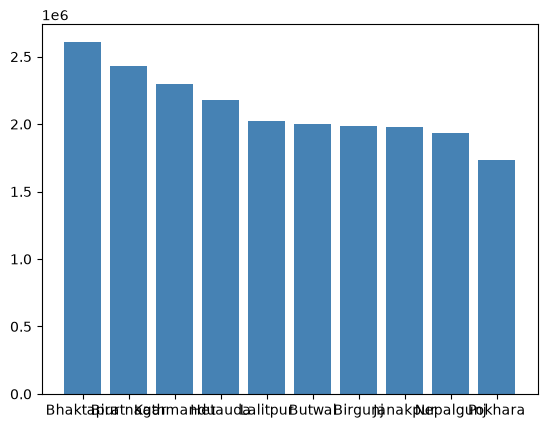

In [99]:
city_sales = invoice.groupby('City')['Total_NPR'].sum().sort_values(ascending=False)
# plt.Figure(figsize=(12,7))
plt.bar(city_sales.index, city_sales.values, color='steelblue')
# plt.title("Total Sales By City")
# plt.ylabel("NPR")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

## Section 3: The Figure / Axes Architecture

The single most important concept in Matplotlib is its **object hierarchy**: Figure → Axes → Artists.

### The three-level hierarchy

```
┌─────────────────────── Figure (the full canvas — the A4 paper) ─────────────────────────┐
│                                                                                          │
│   ┌──────────────────── Axes (one plot area) ────────────────────────────────────────┐  │
│   │                                                                                  │  │
│   │   Title                                                                          │  │
│   │                                                                                  │  │
│   │   Y-axis   ──── Artist objects ────────────────────────────────────────────      │  │
│   │   label   (Lines, Bars, Patches, Text, Markers, Grid lines, Tick marks…)         │  │
│   │                                                                                  │  │
│   │                          X-axis label                                            │  │
│   └──────────────────────────────────────────────────────────────────────────────────┘  │
│                                   Legend (attached to Figure or Axes)                    │
└──────────────────────────────────────────────────────────────────────────────────────────┘
```

### Level 1: Figure

The **Figure** is the entire window or page. Think of it as the blank A4 sheet of paper.

- Created with: `fig = plt.figure()` or `fig, ax = plt.subplots()`
- Controls: overall size (`figsize`), resolution (`dpi`), background colour
- A Figure can contain **multiple Axes** (subplots — this is why we call `plt.subplots()`)

### Level 2: Axes

The **Axes** is the actual chart area — the space where data is plotted.

- One Figure → one or more Axes
- Each Axes has its own X-axis, Y-axis, title, legend
- Created with: `fig, ax = plt.subplots()` (one Axes) or `fig, axes = plt.subplots(2, 2)` (grid)

### Level 3: Artists

**Artists** are everything you can see on the Axes:
- Lines (`Line2D`): `ax.plot()`
- Rectangles (`Rectangle`): `ax.bar()`
- Text (`Text`): `ax.set_title()`, `ax.annotate()`
- Markers, tick labels, grid lines, spines — all Artists

> **Why this matters:** Once you understand Figure → Axes → Artists, every Matplotlib command makes sense. `ax.set_title()` sets the title of the Axes. `fig.suptitle()` sets the title of the Figure. `fig.set_size_inches()` resizes the canvas.

### Practice 2
Group `invoices` by `Product` (sum of `Amount_NPR`). Make a bar chart of the result.

### Pie Chart

In [107]:
status = invoice["Payment_Status"].value_counts()
# display(status)
plt.figure(figsize=(6,6))
# plt.pie(status.values, labels=status.index, autopct='%1.1f%%')

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

(array([32., 28., 32., 18., 12., 22.,  6., 12.,  5.,  6.,  6.,  4.,  6.,
         2.,  2.,  3.,  1.,  0.,  2.,  1.]),
 array([   891.  ,  20225.95,  39560.9 ,  58895.85,  78230.8 ,  97565.75,
        116900.7 , 136235.65, 155570.6 , 174905.55, 194240.5 , 213575.45,
        232910.4 , 252245.35, 271580.3 , 290915.25, 310250.2 , 329585.15,
        348920.1 , 368255.05, 387590.  ]),
 <BarContainer object of 20 artists>)

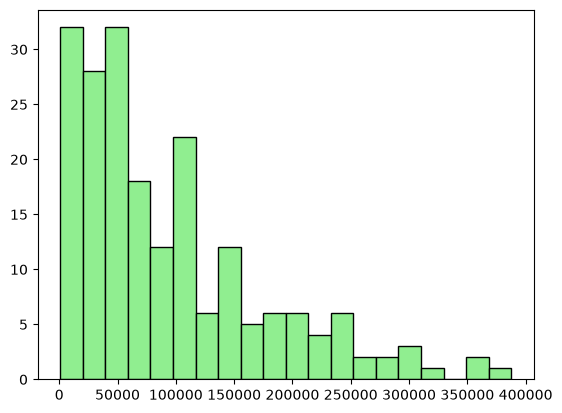

In [ ]:
# Histogram

plt.hist(invoice["Amount_NPR"], bins=20, color='lightgreen', edgecolor='black')

### Histogram